## Astro kod

### Parser

In [9]:
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from parser import parseFits

# Parsea fits data för de tre AGB-stjärnorna
R_Dor = parseFits("data/RDor/")
R_Leo = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/")
W_Hya = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/")

### Centrum metoder
Beräkna centrum

In [10]:
# Centrum metoder

from center_plots import plotMethods
from center_methods import getCenters, maxIntensitet, gaussIntensitet, halvaMax, halvaViktad, halvaLSQ, moffat
from astro_data_format import toAstroData, fromAstroData

method_names = {}

stars = {'R_Dor': R_Dor, 'R_Leo': R_Leo, 'W_Hya': W_Hya}
methods = {'MaxInt': maxIntensitet, 'Gauss': gaussIntensitet, 'HalfMax': halvaMax, 'HalfViktad': halvaViktad, 'HalfLSQ': halvaLSQ, 'Moffat': moffat}

star_travel_dict = {}

def calcAllCenterMethods():
    for method_name, method in methods.items():
        for star_name, star in stars.items():
            print(f"Calculating centers for star {star_name}, with method {method_name}")
            centers = getCenters(method, star)
            toAstroData(fname = f"{star_name}_{method_name}.astrom.dat", header=f"name = {star_name} - {method_name}", data=centers)

# Avkommentera för att räkna ut alla centrum... görs helst inte ofta... tar sin lilla stund 💅
calcAllCenterMethods()

Calculating centers for star R_Dor, with method MaxInt
Calculating centers for star R_Leo, with method MaxInt
Calculating centers for star W_Hya, with method MaxInt
Calculating centers for star R_Dor, with method Gauss
Calculating centers for star R_Leo, with method Gauss
Calculating centers for star W_Hya, with method Gauss


Hämta centrum

In [ ]:
R_Dor_MaxInt = fromAstroData(f"R_Dor_MaxInt.astrom.dat")
R_Dor_Gauss = fromAstroData(f"R_Dor_Gauss.astrom.dat")
R_Leo_MaxInt = fromAstroData(f"R_Leo_MaxInt.astrom.dat")
R_Leo_Gauss = fromAstroData(f"R_Leo_Gauss.astrom.dat")
W_Hya_MaxInt = fromAstroData(f"W_Hya_MaxInt.astrom.dat")
W_Hya_Gauss = fromAstroData(f"W_Hya_Gauss.astrom.dat")

[<Time object: scale='utc' format='decimalyear' value=2017.732>
 <Time object: scale='utc' format='decimalyear' value=2017.735>
 <Time object: scale='utc' format='decimalyear' value=2017.812>
 <Time object: scale='utc' format='decimalyear' value=2017.855>
 <Time object: scale='utc' format='decimalyear' value=2023.568>
 <Time object: scale='utc' format='decimalyear' value=2023.585>
 <Time object: scale='utc' format='decimalyear' value=2023.626>
 <Time object: scale='utc' format='decimalyear' value=2023.749>
 <Time object: scale='utc' format='decimalyear' value=2023.757>
 <Time object: scale='utc' format='decimalyear' value=2023.757>
 <Time object: scale='utc' format='decimalyear' value=2023.763>
 <Time object: scale='utc' format='decimalyear' value=2023.763>
 <Time object: scale='utc' format='decimalyear' value=2023.771>
 <Time object: scale='utc' format='decimalyear' value=2023.771>
 <Time object: scale='utc' format='decimalyear' value=2023.779>
 <Time object: scale='utc' format='decim

### Parallax (+Bootstrap)

In [12]:
import astropy.units as u
import jplephem # Need to install
from astropy.coordinates import solar_system_ephemeris

solar_system_ephemeris.set("jpl")

# Use astropy to get earths barycentric coordinates at time t
def bary_coords(t, ref_t):

    date = aspy.time.Time(t + ref_t, format = 'decimalyear')
    Epos = aspy.coordinates.get_body_barycentric('earth', date)

    X = Epos.x.to(u.au).value
    Y = Epos.y.to(u.au).value
    Z = Epos.z.to(u.au).value
    return X, Y, Z


# our model of the motion
def model(t, ref_t, *params):

    ra0, dec0, parallax, pm_ra, pm_dec = params
    X, Y, Z = bary_coords(t, ref_t)

    ra_model = ra0 + (pm_ra/np.cos(dec0))*t + (parallax/np.cos(dec0))*(X*np.sin(ra0) - Y*np.cos(ra0))
    dec_model = dec0 + pm_dec*t + parallax*(X*np.cos(ra0)*np.sin(dec0) + Y*np.sin(ra0)*np.sin(dec0) - Z*np.cos(dec0))

    return ra_model, dec_model

# Same as model, but without proper motion
def model_wopm(t, ref_t, *params):

    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    X, Y, Z = bary_coords(t, ref_t)

    ra_model = ra0 + (parallax/np.cos(dec0))*(X*np.sin(ra0) - Y*np.cos(ra0))
    dec_model = dec0 + parallax*(X*np.cos(ra0)*np.sin(dec0) + Y*np.sin(ra0)*np.sin(dec0) - Z*np.cos(dec0))

    return ra_model, dec_model

# Take observations, and remove its proper motion
def model_subtract_pm(t, ras, decs, *params):
    
    ra0, dec0, parallax, pm_ra, pm_dec = params
        
    ra_sub_pm = ras - ((pm_ra/np.cos(dec0)) * t)
    dec_sub_pm = decs - (pm_dec * t)
    #print(f'ras before: {ras}, ras after {ra_sub_pm}')
    #print(f'decs before: {decs}, decs after {dec_sub_pm}')
    return ra_sub_pm, dec_sub_pm


# residuals to use with least square fitting
def residuals(params, t, ref_t, ras, decs):
    
    ra_model, dec_model = model(t, ref_t, *params)

    residual_ra = (ras - ra_model) * np.cos(dec_model)
    residual_dec = decs - dec_model

    return np.concatenate([residual_ra, residual_dec])


# Function to fit for parameters
def fit_model(t, ref_t, ras, decs, initial, bounds):

    result = sci.optimize.least_squares(residuals, initial,  args = (t, ref_t, ras, decs), max_nfev=5000, bounds = bounds)

    return result

# Function for using bootstrap to get uncertainties in data
def bootstrap(t, ref_t, ras, decs, result, bounds, n_boot=1000):
    
    ra_model, dec_model = model(t, ref_t, *result.x)

    res_ra = ras - ra_model
    res_dec = decs - dec_model

    n = len(t)

    param_samples = []
    
    for i in range(n_boot):
        idx = np.random.randint(0,n,n)

        ra_boot = ra_model + res_ra[idx]
        dec_boot = dec_model + res_dec[idx]
        try:
            res_boot = fit_model(t, ref_t, ra_boot, dec_boot, result.x, bounds)

            param_samples.append(res_boot.x)
        except Exception:
            continue

    print(f'Bootstrap success: {len(param_samples)}/{n_boot}')
    
    return np.array(param_samples)

In [13]:

# Make plots to visualise the result
def makeplots(name, result, t, ref_t, ras, decs):
    # make some hypothetical dates to use for plots
    hypothetical = np.linspace(t[0], t[-1], 1000)
    hypothetical_extended = np.linspace(t[0]-1, t[-1]+1, 1000)
    hypothetical_year = np.linspace(t[0], t[0]+1, 1000)

    ra_mod, dec_mod = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_long, dec_mod_long = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_wopm, dec_mod_wopm = model_wopm(hypothetical_extended, ref_t, *result.x)
    ra_wopm, dec_wopm = model_subtract_pm(t, ras, decs, *result.x)
    
    # convert fitted parameters to mas
    params = np.rad2deg(result.x)*3.6e6 
    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    # Keep ra0 and dec0 in radians
    ra0 = np.deg2rad(ra0/3.6e6) 
    dec0 = np.deg2rad(dec0/3.6e6)

    # Plot how dRA and dDec changes with time, with and without proper motion
    fig, ax = plt.subplots(3,2, figsize = (15,8), dpi = 120)
    fig.subplots_adjust(hspace=0)
    plt.suptitle(name)

    # dDec
    ax[0][0].set_title('With proper motion')
    ax[0][0].plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod-dec0), zorder = 0)
    ax[0][0].scatter(t, 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
    ax[0][0].set_ylabel(r'$\Delta\delta$ [mas]')

    # dRA
    ax[1][0].plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod-ra0), zorder = 0)
    ax[1][0].scatter(t, 3.6e6*np.rad2deg(ras-ra0), color = 'orange', zorder = 1)
    ax[1][0].set_xlabel(r'$\Delta t$ [years]')
    ax[1][0].set_ylabel(r'$\Delta\alpha$ [mas]')
    
    ax[0][0].sharex(ax[1][0])
        # Plot how dRA and dDec changes with time, without proper moiton
    ax[0][1].set_title('Without proper motion')
    ax[0][1].plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
    ax[0][1].scatter(t, 3.6e6*np.rad2deg(dec_wopm-dec0), color = 'orange')
    ax[0][1].set_ylabel(r'$\Delta\delta$ [mas]')


    ax[1][1].plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod_wopm-ra0))
    ax[1][1].scatter(t, 3.6e6*np.rad2deg(ra_wopm-ra0), color = 'orange')
    ax[1][1].set_ylabel(r'$\Delta\alpha$ [mas]')

    ax[1][0].sharex(ax[1][1])
    ax[1][0].set_xlabel(r'$\Delta t$ [years]')    
    ax[1][1].set_xlabel(r'$\Delta t$ [years]')

    # Plot how the star moves on the sky, dRA vs dDec, with and without proper motion    
    # With proper motion
    ax[2][0].plot(3.6e6*np.rad2deg(ra_mod_long-ra0), 3.6e6*np.rad2deg(dec_mod_long-dec0), zorder = 0)
    ax[2][0].scatter(3.6e6*np.rad2deg(ras-ra0), 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
    ax[2][0].axis('equal') # 1 grad RA = 1 grad dec
    ax[2][0].invert_xaxis()
    ax[2][0].set_title(r'Dec vs RA with proper motion')
    ax[2][0].set_xlabel(r'$\Delta\alpha$ [mas]')
    ax[2][0].set_ylabel(r'$\Delta\delta$ [mas]')


    # Without proper motion
    ax[2][1].plot(3.6e6*np.rad2deg(ra_mod_wopm-ra0), 3.6e6*np.rad2deg(dec_mod_wopm-dec0), zorder = 0)
    ax[2][1].scatter(3.6e6*np.rad2deg(ra_wopm-ra0), 3.6e6*np.rad2deg(dec_wopm-dec0), color = 'orange', zorder = 1)
    ax[2][1].axis('equal') # 1 grad RA = 1 grad dec
    ax[2][1].set_title(r'Dec vs RA without proper motion')
    ax[2][1].set_xlabel(r'$\Delta\alpha$ [mas]')
    ax[2][1].set_ylabel(r'$\Delta\delta$ [mas]')

    plt.show()

import matplotlib.gridspec as gridspec

def makeplots2(name, result, t, ref_t, ras, decs):

    hypothetical = np.linspace(t[0], t[-1], 1000)
    hypothetical_extended = np.linspace(t[0]-1, t[-1]+1, 1000)

    ra_mod, dec_mod = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_long, dec_mod_long = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_wopm, dec_mod_wopm = model_wopm(hypothetical_extended, ref_t, *result.x)
    ra_wopm, dec_wopm = model_subtract_pm(t, ras, decs, *result.x)
    
    params = np.rad2deg(result.x)*3.6e6 
    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    ra0 = np.deg2rad(ra0/3.6e6) 
    dec0 = np.deg2rad(dec0/3.6e6)

    fig = plt.figure(figsize=(15, 10), dpi=120)
    plt.suptitle(name)

    # Outer grid: 2 blocks (top + bottom)
    outer = gridspec.GridSpec(2, 1, height_ratios=[2, 2], hspace=0.4)

    # Top block (2x2, no spacing)
    top = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0], hspace=0)

    ax00 = fig.add_subplot(top[0, 0])
    ax10 = fig.add_subplot(top[1, 0], sharex=ax00)

    ax01 = fig.add_subplot(top[0, 1])
    ax11 = fig.add_subplot(top[1, 1], sharex=ax01)

    # Bottom block (normal spacing)
    bottom = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1])

    ax20 = fig.add_subplot(bottom[0, 0])
    ax21 = fig.add_subplot(bottom[0, 1])

    # --- PLOTTING (same as your code) ---

    # With proper motion
    ax00.set_title('With proper motion')
    ax00.plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod-dec0))
    ax00.scatter(t, 3.6e6*np.rad2deg(decs-dec0), color='orange')
    ax00.set_ylabel(r'$\Delta\delta$ [mas]')
    ax00.tick_params(labelbottom=False)

    ax10.plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod-ra0))
    ax10.scatter(t, 3.6e6*np.rad2deg(ras-ra0), color='orange')
    ax10.set_ylabel(r'$\Delta\alpha$ [mas]')
    ax10.set_xlabel(r'$\Delta t$ [years]')

    # Without proper motion
    ax01.set_title('Without proper motion')
    ax01.plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
    ax01.scatter(t, 3.6e6*np.rad2deg(dec_wopm-dec0), color='orange')
    ax01.set_ylabel(r'$\Delta\delta$ [mas]')
    ax01.tick_params(labelbottom=False)

    ax11.plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod_wopm-ra0))
    ax11.scatter(t, 3.6e6*np.rad2deg(ra_wopm-ra0), color='orange')
    ax11.set_ylabel(r'$\Delta\alpha$ [mas]')
    ax11.set_xlabel(r'$\Delta t$ [years]')

    # Sky plots (separate spacing!)
    ax20.plot(3.6e6*np.rad2deg(ra_mod_long-ra0), 3.6e6*np.rad2deg(dec_mod_long-dec0))
    ax20.scatter(3.6e6*np.rad2deg(ras-ra0), 3.6e6*np.rad2deg(decs-dec0), color='orange')
    ax20.axis('equal')
    ax20.invert_xaxis()
    ax20.set_title('Dec vs RA with proper motion')
    ax20.set_xlabel(r'$\Delta\alpha$ [mas]')
    ax20.set_ylabel(r'$\Delta\delta$ [mas]')

    ax21.plot(3.6e6*np.rad2deg(ra_mod_wopm-ra0), 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
    ax21.scatter(3.6e6*np.rad2deg(ra_wopm-ra0), 3.6e6*np.rad2deg(dec_wopm-dec0), color='orange')
    ax21.axis('equal')
    ax21.set_title('Dec vs RA without proper motion')
    ax21.set_xlabel(r'$\Delta\alpha$ [mas]')
    ax21.set_ylabel(r'$\Delta\delta$ [mas]')

    plt.show()

### Analys

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.461 ± 2.906 mas (68% CI: [528802351.671, 528802357.328])
dec0: 41142898.281 ± 1.950 mas (68% CI: [41142896.315, 41142900.185])
parallax: 15.949 ± 2.146 mas (68% CI: [13.863, 18.102])
pm_ra: 0.269 ± 0.379 mas (68% CI: [-0.119, 0.628])
pm_dec: -42.846 ± 0.326 mas (68% CI: [-43.185, -42.526])
Distance: 67.611 ± 9.810 parsec

Best fit results:
ra0: 528802354.595 ± 3.565 mas
dec0: 41142898.295 ± 2.285 mas
parallax: 15.802 ± 3.332 mas
pm_ra: 0.256 ± 0.400 mas
pm_dec: -42.856 ± 0.369 mas
Distance: 63.281 ± 13.342 parsec


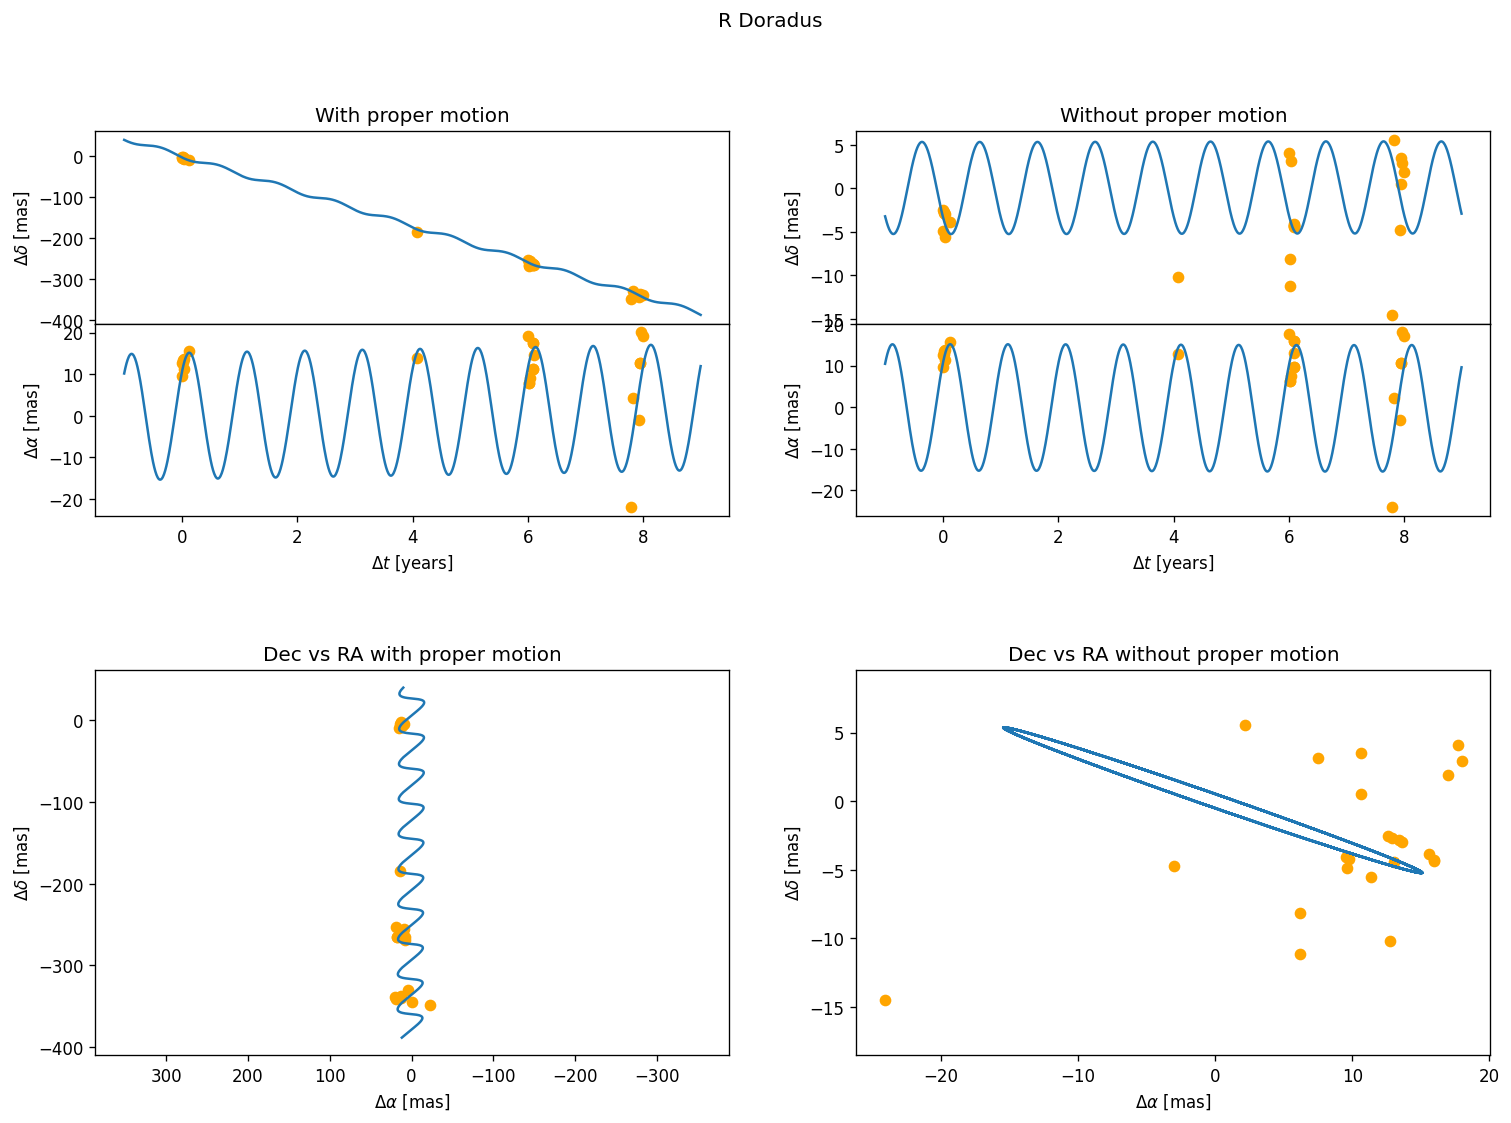

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 746129086.260 ± 1.831 mas (68% CI: [746129084.416, 746129088.108])
dec0: -99475514.374 ± 1.173 mas (68% CI: [-99475515.576, -99475513.160])
parallax: 9.495 ± 1.783 mas (68% CI: [7.844, 11.366])
pm_ra: -49.698 ± 0.283 mas (68% CI: [-49.990, -49.421])
pm_dec: 60.319 ± 0.171 mas (68% CI: [60.143, 60.496])
Distance: 82.772 ± 12.215 parsec

Best fit results:
ra0: 746129086.290 ± 1.835 mas
dec0: -99475514.327 ± 1.442 mas
parallax: 9.332 ± 2.084 mas
pm_ra: -49.712 ± 0.303 mas
pm_dec: 60.323 ± 0.204 mas
Distance: 107.162 ± 23.936 parsec


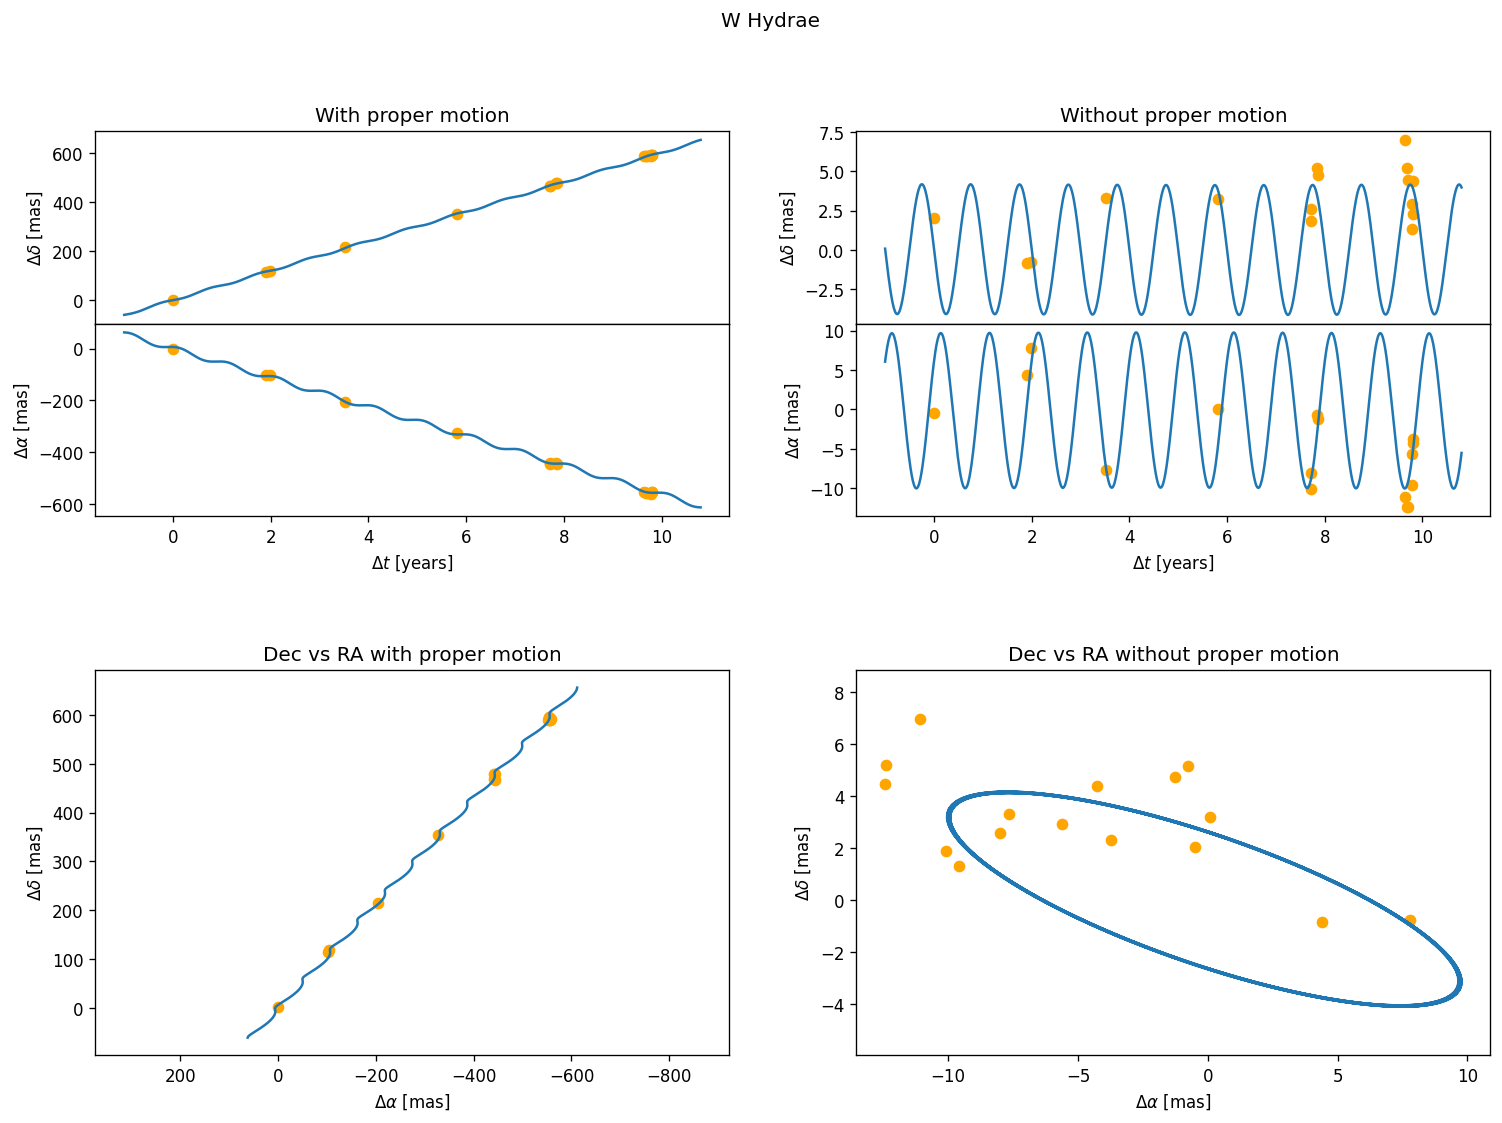

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.825 ± 3.579 mas (68% CI: [528802351.211, 528802358.454])
dec0: 41142898.698 ± 2.440 mas (68% CI: [41142896.429, 41142901.051])
parallax: 16.370 ± 2.810 mas (68% CI: [13.766, 19.012])
pm_ra: -0.113 ± 0.488 mas (68% CI: [-0.604, 0.360])
pm_dec: -43.134 ± 0.414 mas (68% CI: [-43.528, -42.727])
Distance: 44.229 ± 5.497 parsec

Best fit results:
ra0: 528802355.009 ± 4.484 mas
dec0: 41142898.732 ± 2.874 mas
parallax: 16.207 ± 4.191 mas
pm_ra: -0.123 ± 0.503 mas
pm_dec: -43.136 ± 0.465 mas
Distance: 61.702 ± 15.956 parsec


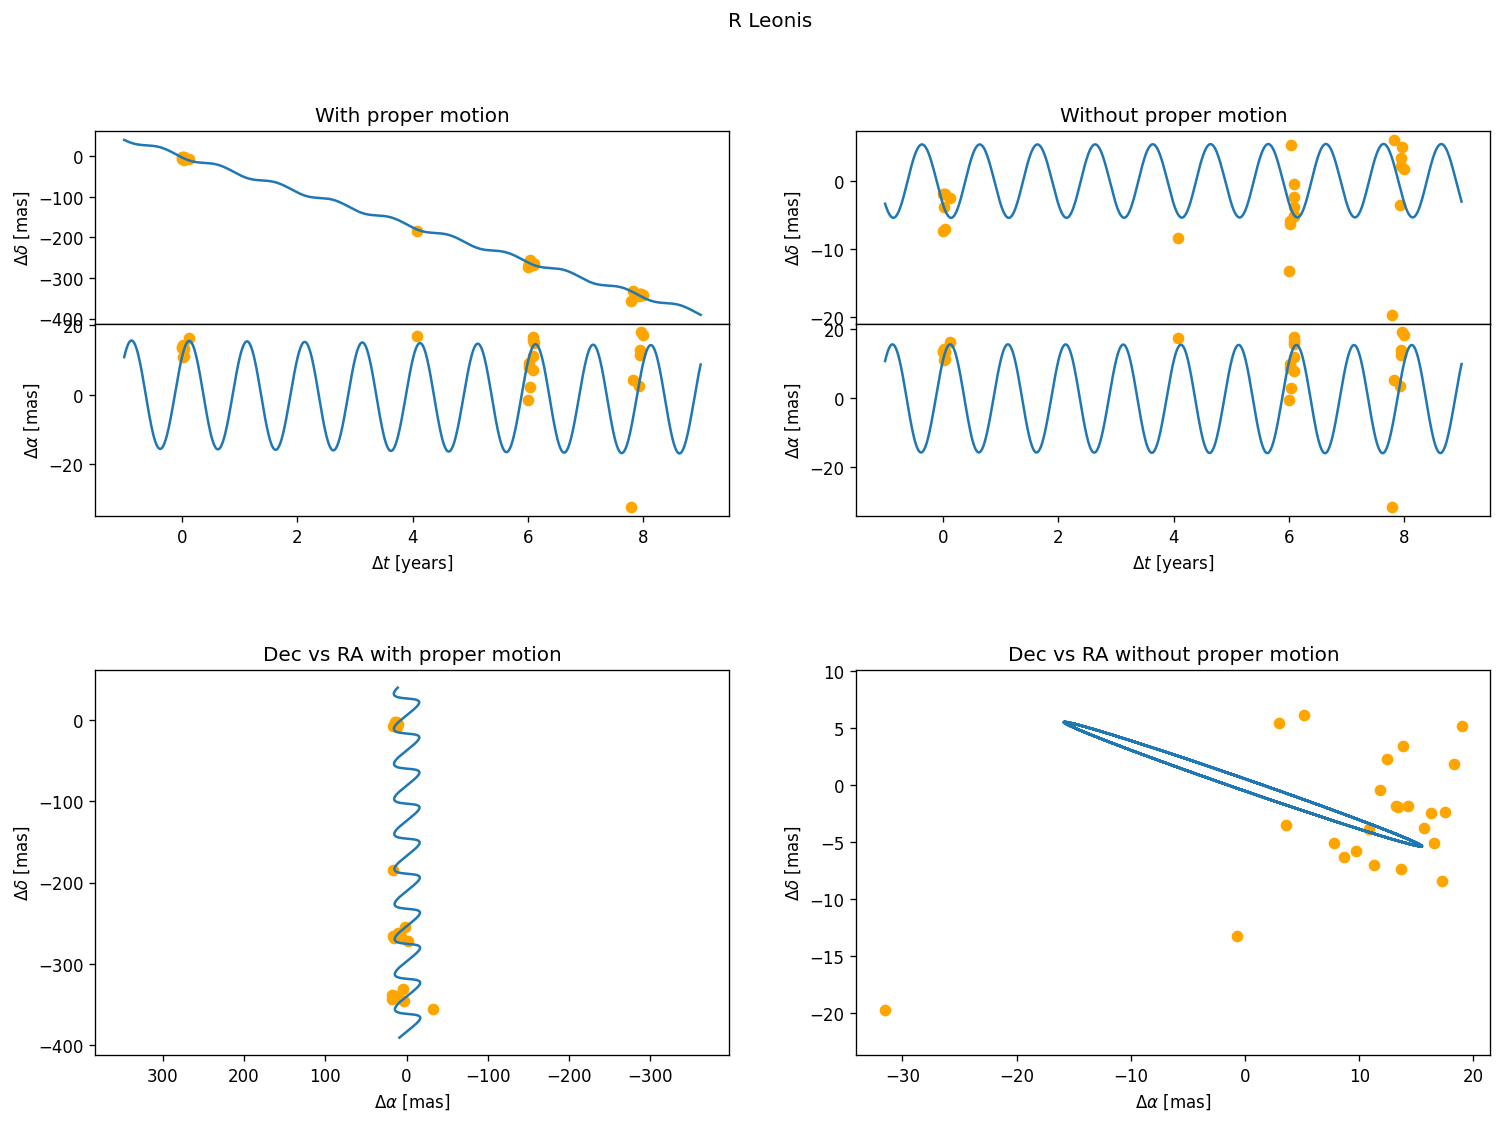

In [ ]:
# Choose star to study
stars = {'R Doradus': [R_Dor_MaxInt, R_Dor_Gauss], 'W Hydrae': [W_Hya_MaxInt, W_Hya_Gauss], 'R Leonis': [R_Leo_MaxInt, R_Leo_Gauss]}
for i in stars:
    name = i
    star = stars[name]
    data = star[1] # 0 = MaxInt, 1 = Gauss


    # Split the data
    date = aspy.time.Time(data[0])
    decs = np.deg2rad(np.asarray(data[2], dtype = float))
    ras = np.deg2rad(np.asarray(data[1], dtype = float))


    # ref_t is our reference epoch
    #ref_t = np.mean(date.decimalyear)
    ref_t = (date.decimalyear)[0]
    t = date.decimalyear - ref_t

    # take an initial guess of the parameters
    masguess = {'R Doradus': 18.31, 'W Hydrae': 10.18, 'R Leonis': 14.06} # initial parallax guess in mas
    initial = [ras[0], decs[0], np.deg2rad(masguess[i]/(3.6e6)), 0., 0.]
    bounds = [(-np.inf, -np.inf, 0., -np.inf, -np.inf), (np.inf, np.inf, np.inf, np.inf, np.inf)]
    # make the fit and get the results
    result = fit_model(t, ref_t, ras, decs, initial, bounds)

    params = np.rad2deg(result.x)*3.6e6 # convert fitted parameters to mas
    ra0, dec0, parallax, pm_ra, pm_dec = params
    ra0 = np.deg2rad(ra0/3.6e6)
    dec0 = np.deg2rad(dec0/3.6e6)


    # Calculate distance
    d_best_fit = 1 / (parallax/1000)
    # Estimate errors
    jacobian = result.jac
    resid = result.fun
    m = len(resid)
    n = len(result.x)
    sigma2 = np.sum(resid**2) / (m - n)
    cov = sigma2 * np.linalg.inv(jacobian.T @ jacobian)

    params_std = np.rad2deg(np.sqrt(np.diag(cov)))*3.6e6

    ra_cal, dec_cal = model(t, ref_t, *result.x)

    # Calculate errors for distance
    d_uncert_best_fit = (1 / ((parallax/1000)**2))*params_std[2]/1000
    # Bootstrap testing
    samples = bootstrap(t, ref_t, ras, decs, result, bounds)
    samples_mas = 3.6e6*np.rad2deg(samples)
    parallax_bootstrap = samples_mas[2][2]

    param_names = ["ra0", "dec0", "parallax", "pm_ra", "pm_dec"]
    d_bootstrap = 1/(parallax_bootstrap/1000)

    means = np.mean(samples_mas, axis=0)
    stds = np.std(samples_mas, axis=0)
    p16 = np.percentile(samples_mas, 16, axis=0)
    p84 = np.percentile(samples_mas, 84, axis=0)

    d_uncert_bootstrap = (1/((parallax_bootstrap/1000)**2))*stds[2]/1000
    print("\nBootstrap results:")
    for i, p_name in enumerate(param_names):
        print(f"{p_name}: {means[i]:.3f} ± {stds[i]:.3f} mas "
            f"(68% CI: [{p16[i]:.3f}, {p84[i]:.3f}])")
    print(f'Distance: {d_bootstrap:.3f} ± {d_uncert_bootstrap:.3f} parsec')


    # print best fit results
    print('\nBest fit results:')
    for i, p_name in enumerate(param_names):
        print(f"{p_name}: {params[i]:.3f} ± {params_std[i]:.3f} mas")

    print(f'Distance: {d_best_fit:.3f} ± {d_uncert_best_fit:.3f} parsec')
    # print(f'Params in rad: {result.x}, params in mas: {params}')
    # print(f'Standard deviation of all parameters in mas: {params_std}')
    # print(f'Parallax: {parallax:.3f} \u00B1 {params_std[2]:.3f} mas')


    makeplots2(name, result, t, ref_t, ras, decs)